# Cancer Lifestyle Medicine - Data Analysis

Dataset: `adult24.csv`

In [120]:
import pandas as pd

df = pd.read_csv('adult24.csv')

## Question CAN.0010.00.1 (ID: 109)

**Variable:** `CANEV_A`  
**Question:** Have you EVER been told by a doctor or other health professional that you had Cancer or a malignancy of any kind?

**Response codes:**
- `1` = Yes
- `2` = No
- `7` = Refused
- `9` = Don't know

In [121]:
# Count of each response for CANEV_A
canev_counts = df['CANEV_A'].value_counts().sort_index()

response_labels = {1: 'Yes (cancer)', 2: 'No', 7: 'Refused', 9: "Don't know"}
canev_counts.index = canev_counts.index.map(response_labels)

print("CANEV_A - Ever told had cancer?")
print(canev_counts.to_string())
print(f"\nTotal respondents: {len(df)}")

CANEV_A - Ever told had cancer?
CANEV_A
Yes (cancer)     4434
No              28165
Refused            21
Don't know          9

Total respondents: 32629


In [122]:
# Number of people who have had cancer (CANEV_A == 1)
num_cancer = (df['CANEV_A'] == 1).sum()
total = df['CANEV_A'].notna().sum()
pct = num_cancer / total * 100

print(f"Number of people who have had cancer (CANEV_A = 1): {num_cancer}")
print(f"Total respondents with a valid answer:               {total}")
print(f"Percentage with cancer:                              {pct:.2f}%")

Number of people who have had cancer (CANEV_A = 1): 4434
Total respondents with a valid answer:               32629
Percentage with cancer:                              13.59%


In [123]:
print(df.shape)

(32629, 630)


In [187]:
vars_needed = [
    "SEX_A",
    "HISPALLP_A",
    "RACEALLP_A",
    "EDUCP_A",
    "CANEV_A",
    "WTFA_A"      # add weight column now
]

analysis_df = df[vars_needed].copy()

analysis_df.head()

,SEX_A,HISPALLP_A,RACEALLP_A,EDUCP_A,CANEV_A,WTFA_A
0,1,2,1,5,2,5780.565
1,1,2,1,5,2,3994.244
2,1,2,1,5,2,6636.755
3,1,2,1,4,2,13767.420
4,2,3,2,9,2,18880.030


In [125]:
analysis_df.isna().sum()

SEX_A         0
HISPALLP_A    0
RACEALLP_A    0
EDUCP_A       0
CANEV_A       0
dtype: int64

In [126]:
analysis_df["SEX_A"].value_counts()

SEX_A
2    17639
1    14985
7        3
9        2
Name: count, dtype: int64

In [127]:
analysis_df["HISPALLP_A"].value_counts()

HISPALLP_A
2    21770
1     4762
3     3296
4     1869
7      411
5      268
6      253
Name: count, dtype: int64

In [128]:
analysis_df["RACEALLP_A"].value_counts()

RACEALLP_A
1    24452
2     3447
3     1894
8     1661
6      476
4      347
5      313
9       32
7        7
Name: count, dtype: int64

In [129]:
analysis_df["EDUCP_A"].value_counts()

EDUCP_A
4     7605
8     7482
5     4698
9     3627
7     3017
1     2131
6     1335
10    1250
3      803
2      534
99     112
97      35
Name: count, dtype: int64

In [188]:
cancer_map = {
    1: "Yes",
    2: "No",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't Know"
}

sex_map = {
    1: "Male",
    2: "Female",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

race_map = {
    1: "White",
    2: "Black/African American",
    3: "American Indian/Alaska Native",
    4: "Asian",
    5: "Native Hawaiian/Pacific Islander",
    6: "Multiple Races",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

educ_map = {
    0: "Never attended",
    1: "Grade 1–11",
    2: "12th grade, no diploma",
    3: "GED",
    4: "High School Graduate",
    5: "Some College",
    6: "Associate (occupational)",
    7: "Associate (academic)",
    8: "Bachelor's",
    9: "Master's",
    10: "Professional/Doctorate",
    97: "Refused",
    98: "Not Ascertained",
    99: "Don't know"
}

In [189]:
analysis_df["SEX_label"] = analysis_df["SEX_A"].map(sex_map)
analysis_df["RACE_label"] = analysis_df["RACEALLP_A"].map(race_map)
analysis_df["EDUC_label"] = analysis_df["EDUCP_A"].map(educ_map)
analysis_df["CANEV_label"] = analysis_df["CANEV_A"].map(cancer_map)

In [190]:
analysis_df[["SEX_A","SEX_label","RACEALLP_A","RACE_label","EDUCP_A","EDUC_label"]].head()

,SEX_A,SEX_label,RACEALLP_A,RACE_label,EDUCP_A,EDUC_label
0,1,Male,1,White,5,Some College
1,1,Male,1,White,5,Some College
2,1,Male,1,White,5,Some College
3,1,Male,1,White,4,High School Graduate
4,2,Female,2,Black/African American,9,Master's


In [191]:
analysis_df["CANEV_label"].value_counts()

CANEV_label
No            28165
Yes            4434
Refused          21
Don't Know        9
Name: count, dtype: int64

In [193]:
clean_df = analysis_df[
    (analysis_df["CANEV_A"].isin([1,2])) &
    (analysis_df["SEX_A"].isin([1,2]))
].copy()

clean_df["SEX_label"] = clean_df["SEX_A"].map(sex_map)
clean_df["RACE_label"] = clean_df["RACEALLP_A"].map(race_map)
clean_df["EDUC_label"] = clean_df["EDUCP_A"].map(educ_map)
clean_df["CANEV_label"] = clean_df["CANEV_A"].map(cancer_map)

In [194]:
clean_df.columns

Index(['SEX_A', 'HISPALLP_A', 'RACEALLP_A', 'EDUCP_A', 'CANEV_A', 'WTFA_A',
       'SEX_label', 'RACE_label', 'EDUC_label', 'CANEV_label'],
      dtype='object')

In [195]:
clean_df["Cancer"] = (clean_df["CANEV_A"] == 1).astype(int)

In [196]:
clean_df.head()

,SEX_A,HISPALLP_A,RACEALLP_A,EDUCP_A,CANEV_A,WTFA_A,SEX_label,RACE_label,EDUC_label,CANEV_label,Cancer
0,1,2,1,5,2,5780.565,Male,White,Some College,No,0
1,1,2,1,5,2,3994.244,Male,White,Some College,No,0
2,1,2,1,5,2,6636.755,Male,White,Some College,No,0
3,1,2,1,4,2,13767.420,Male,White,High School Graduate,No,0
4,2,3,2,9,2,18880.030,Female,Black/African American,Master's,No,0


In [197]:
clean_df["CANEV_label"].value_counts(normalize=True)*100

CANEV_label
No     86.396269
Yes    13.603731
Name: proportion, dtype: float64

In [198]:
pd.crosstab(clean_df["SEX_label"], clean_df["CANEV_label"], normalize="index")

CANEV_label,No,Yes
SEX_label,,
Female,0.858513,0.141487
Male,0.870382,0.129618


In [172]:
pd.crosstab(clean_df["RACE_label"], clean_df["CANEV_label"], normalize="index")

CANEV_label,No,Yes
RACE_label,,
American Indian/Alaska Native,0.950343,0.049657
Asian,0.893372,0.106628
Black/African American,0.916110,0.083890
Don't know,0.937500,0.062500
Multiple Races,0.964211,0.035789
Native Hawaiian/Pacific Islander,0.843450,0.156550
Not Ascertained,0.962048,0.037952
Refused,1.000000,0.000000
White,0.841004,0.158996


In [173]:
pd.crosstab(clean_df["EDUC_label"], clean_df["CANEV_label"], normalize="index")

CANEV_label,No,Yes
EDUC_label,,
"12th grade, no diploma",0.889513,0.110487
Associate (academic),0.863546,0.136454
Associate (occupational),0.851574,0.148426
Bachelor's,0.861100,0.138900
Don't know,0.928571,0.071429
GED,0.863014,0.136986
Grade 1–11,0.884922,0.115078
High School Graduate,0.869571,0.130429
Master's,0.853753,0.146247


In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

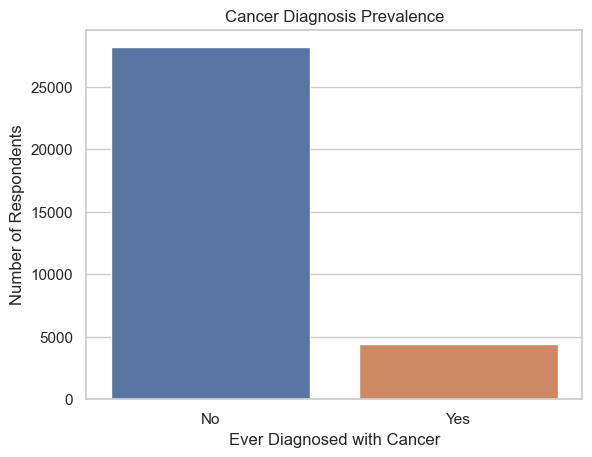

In [175]:
sns.countplot(data=clean_df, x="CANEV_label")

plt.title("Cancer Diagnosis Prevalence")
plt.xlabel("Ever Diagnosed with Cancer")
plt.ylabel("Number of Respondents")

plt.show()

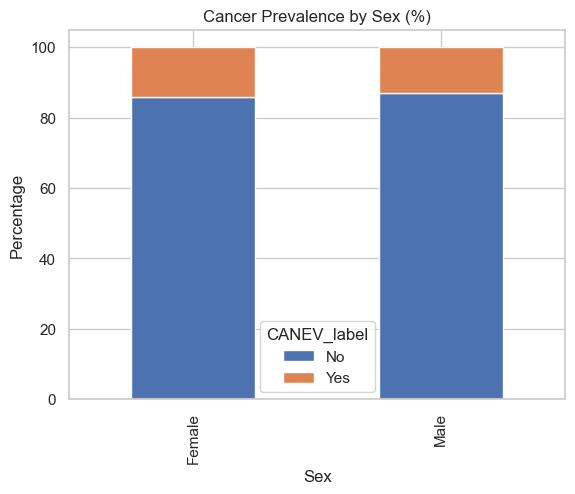

In [200]:
sex_table = pd.crosstab(clean_df["SEX_label"], clean_df["CANEV_label"], normalize="index")

(sex_table*100).plot(kind="bar", stacked=True)

plt.title("Cancer Prevalence by Sex (%)")
plt.xlabel("Sex")
plt.ylabel("Percentage")

plt.show()

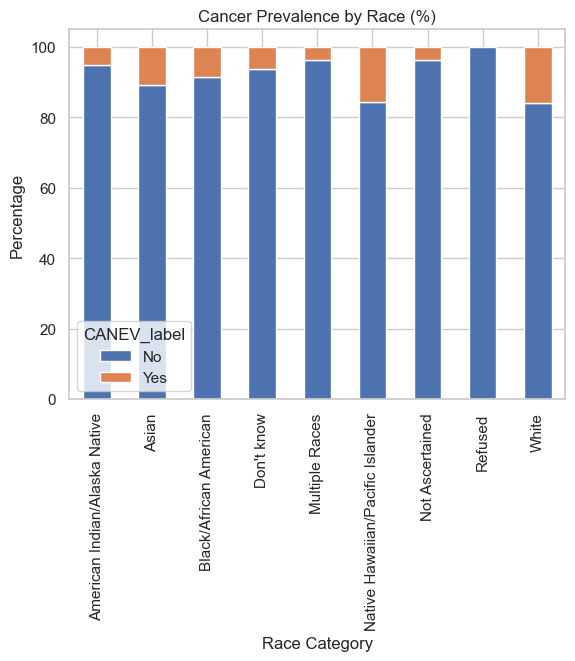

In [201]:
race_table = pd.crosstab(clean_df["RACE_label"], clean_df["CANEV_label"], normalize="index")

(race_table*100).plot(kind="bar", stacked=True)

plt.title("Cancer Prevalence by Race (%)")
plt.xlabel("Race Category")
plt.ylabel("Percentage")

plt.show()

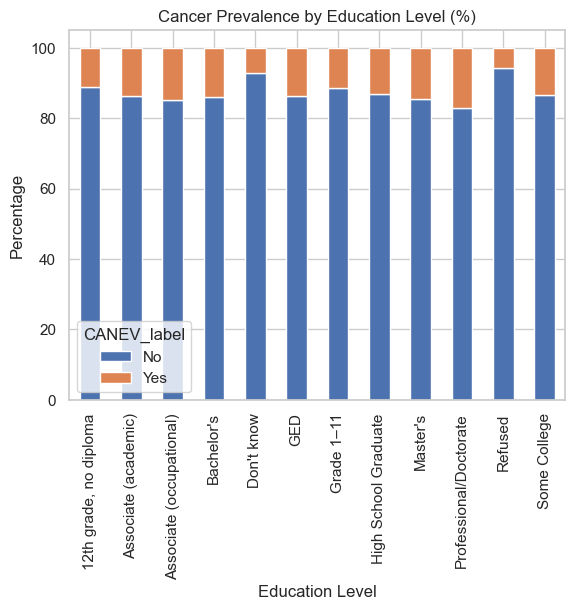

In [202]:
edu_table = pd.crosstab(clean_df["EDUC_label"], clean_df["CANEV_label"], normalize="index")

(edu_table*100).plot(kind="bar", stacked=True)

plt.title("Cancer Prevalence by Education Level (%)")
plt.xlabel("Education Level")
plt.ylabel("Percentage")

plt.show()

In [203]:
heatmap_data = (
    clean_df
    .groupby(["RACE_label","EDUC_label"])["Cancer"]
    .mean()
    .unstack()
)

# rows = race
# columns = education
# values = cancer prevalence (proportion with cancer)

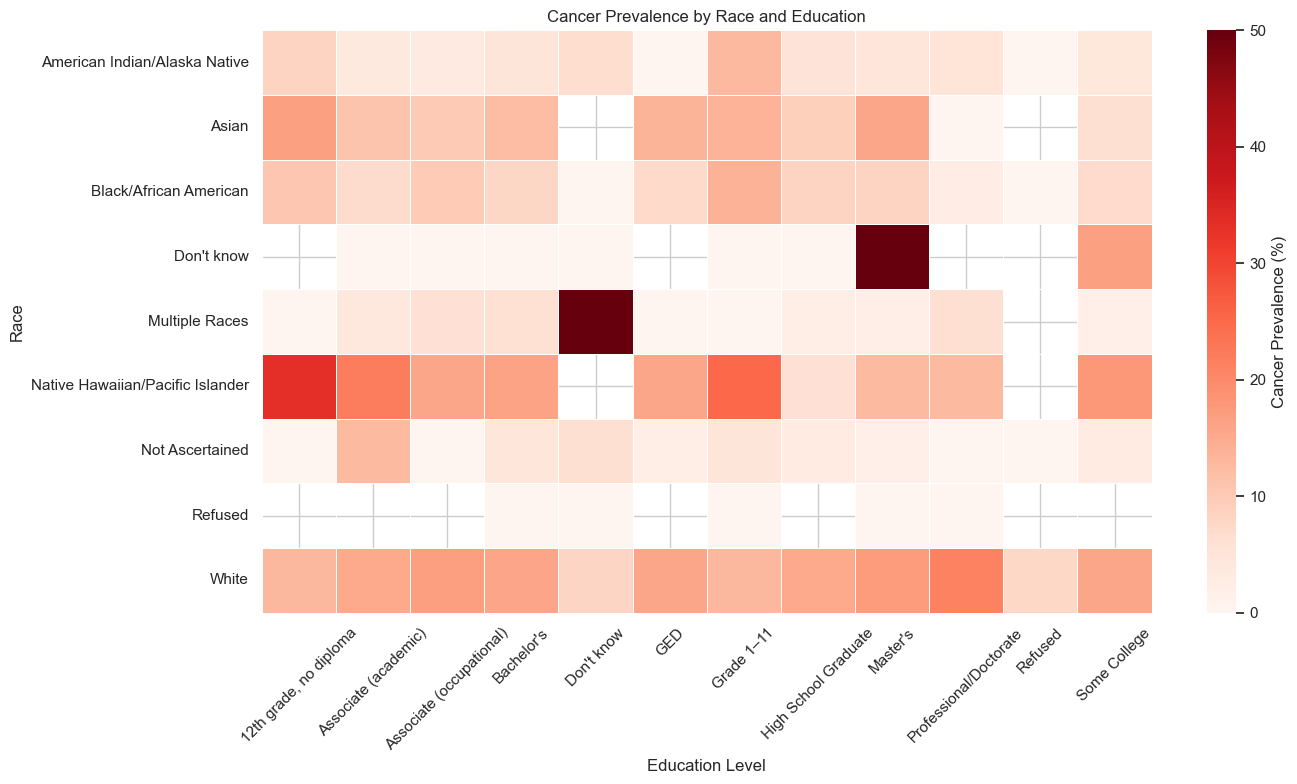

In [204]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data * 100,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label":"Cancer Prevalence (%)"}
)

plt.title("Cancer Prevalence by Race and Education")
plt.xlabel("Education Level")
plt.ylabel("Race")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

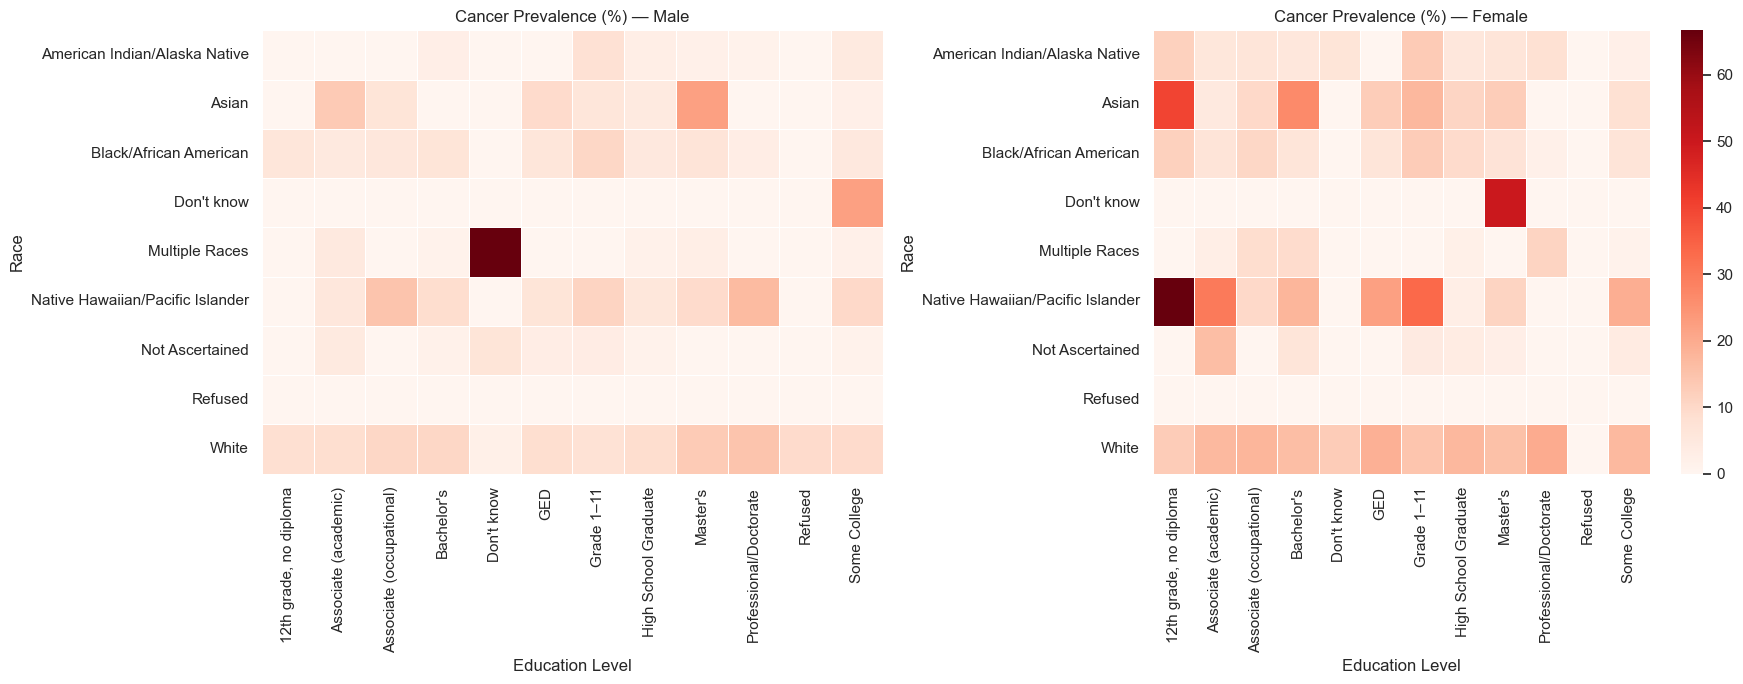

In [181]:
fig, axes = plt.subplots(1,2, figsize=(18,7))

for i, sex in enumerate(["Male","Female"]):

    subset = clean_df[clean_df["SEX_label"] == sex]

    data = (
        subset
        .groupby(["RACE_label","EDUC_label"])["Cancer"]
        .mean()
        .unstack()
        .fillna(0)
    )

    sns.heatmap(
        data * 100,
        fmt=".1f",
        cmap="Reds",
        linewidths=0.5,
        ax=axes[i],
        cbar=i==1
    )

    axes[i].set_title(f"Cancer Prevalence (%) — {sex}")
    axes[i].set_xlabel("Education Level")
    axes[i].set_ylabel("Race")

plt.tight_layout()
plt.show()

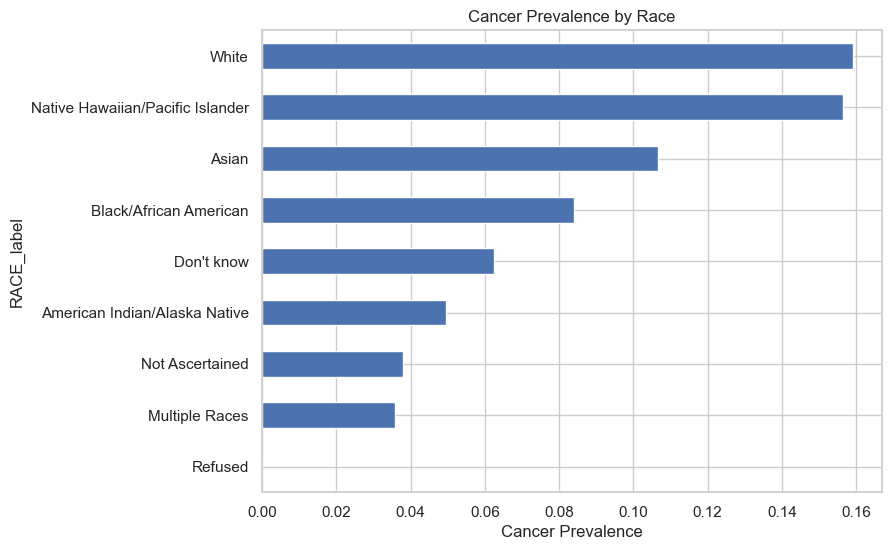

In [206]:
demo_rates = (
    clean_df
    .groupby("RACE_label")["Cancer"]
    .mean()
    .sort_values()
)

demo_rates.plot(kind="barh", figsize=(8,6))

plt.xlabel("Cancer Prevalence")
plt.title("Cancer Prevalence by Race")

plt.show()

In [183]:
vars_needed = [
    "SEX_A",
    "RACEALLP_A",
    "EDUCP_A",
    "CANEV_A",
    "WTFA_A"
]

analysis_df = df[vars_needed].copy()

In [184]:
clean_df = analysis_df[analysis_df["CANEV_A"].isin([1,2])].copy()

clean_df["Cancer"] = (clean_df["CANEV_A"] == 1).astype(int)

In [185]:
import numpy as np

def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)

In [211]:
overall_prev = weighted_mean(clean_df["Cancer"], clean_df["WTFA_A"])

print("Weighted Cancer Prevalence:", overall_prev*100)

Weighted Cancer Prevalence: 10.277411469615554


In [212]:
weighted_race = (
    clean_df
    .groupby("RACE_label")
    .apply(lambda x: weighted_mean(x["Cancer"], x["WTFA_A"]))
)

weighted_race = weighted_race.sort_values(ascending=False)

weighted_race * 100

RACE_label
White                               12.320137
Native Hawaiian/Pacific Islander    10.962477
Asian                                9.248783
Black/African American               6.410137
American Indian/Alaska Native        5.087611
Don't know                           4.619274
Not Ascertained                      2.910887
Multiple Races                       2.879222
Refused                              0.000000
dtype: float64

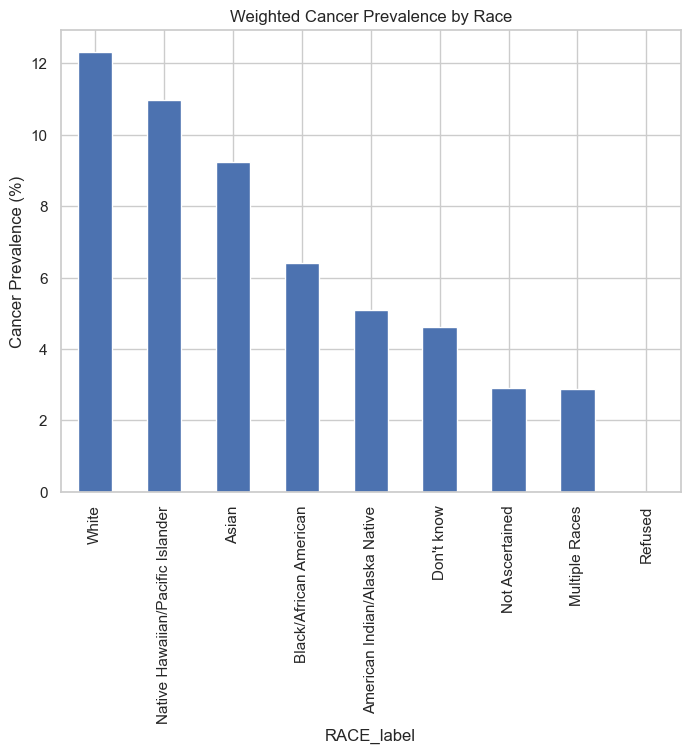

In [214]:
(weighted_race*100).plot(kind="bar", figsize=(8,6))

plt.ylabel("Cancer Prevalence (%)")
plt.title("Weighted Cancer Prevalence by Race")

plt.show()

In [215]:
weighted_heatmap = (
    clean_df
    .groupby(["RACE_label","EDUC_label"])
    .apply(lambda x: weighted_mean(x["Cancer"], x["WTFA_A"]))
    .unstack()
)

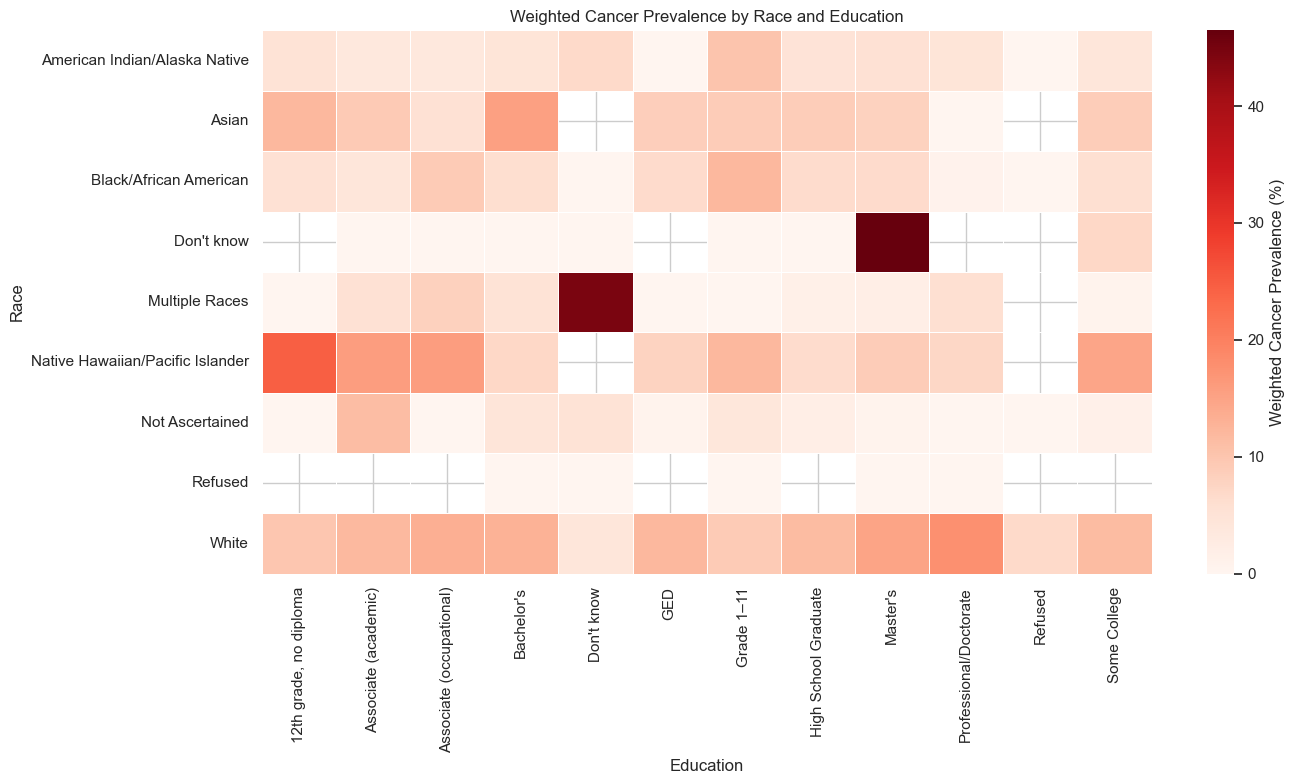

In [219]:
plt.figure(figsize=(14,8))

sns.heatmap(
    weighted_heatmap*100,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label":"Weighted Cancer Prevalence (%)"}
)

plt.title("Weighted Cancer Prevalence by Race and Education")
plt.xlabel("Education")
plt.ylabel("Race")

plt.tight_layout()

plt.show()

In [220]:
def weighted_se(x, w):
    p = weighted_mean(x, w)
    n_eff = (np.sum(w)**2) / np.sum(w**2)
    return np.sqrt(p*(1-p)/n_eff)

In [221]:
results = []

for race, group in clean_df.groupby("RACE_label"):
    
    p = weighted_mean(group["Cancer"], group["WTFA_A"])
    se = weighted_se(group["Cancer"], group["WTFA_A"])
    
    ci_low = p - 1.96*se
    ci_high = p + 1.96*se
    
    results.append({
        "Race": race,
        "Prevalence": p*100,
        "CI_low": ci_low*100,
        "CI_high": ci_high*100
    })

race_results = pd.DataFrame(results)

race_results

,Race,Prevalence,CI_low,CI_high
0,American Indian/Alaska Native,5.087611,3.904016,6.271207
1,Asian,9.248783,5.228055,13.269512
2,Black/African American,6.410137,5.376174,7.444100
3,Don't know,4.619274,-4.021725,13.260272
4,Multiple Races,2.879222,1.036097,4.722347
5,Native Hawaiian/Pacific Islander,10.962477,6.414488,15.510465
6,Not Ascertained,2.910887,1.955782,3.865993
7,Refused,0.000000,0.000000,0.000000
8,White,12.320137,11.813902,12.826371


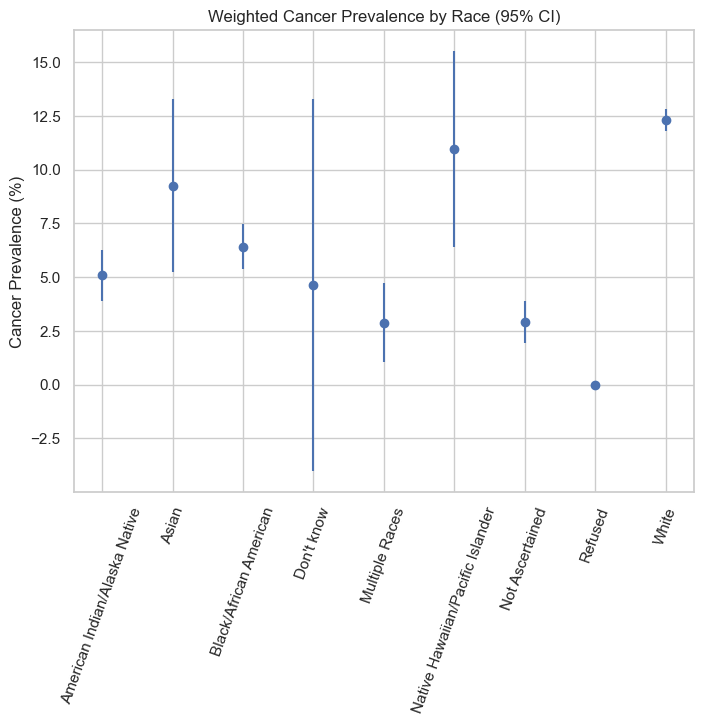

In [227]:
plt.figure(figsize=(8,6))

plt.errorbar(
    race_results["Race"],
    race_results["Prevalence"],
    yerr=[
        race_results["Prevalence"] - race_results["CI_low"],
        race_results["CI_high"] - race_results["Prevalence"]
    ],
    fmt='o'
)

plt.ylabel("Cancer Prevalence (%)")
plt.title("Weighted Cancer Prevalence by Race (95% CI)")

plt.xticks(rotation=70)
plt.show()

In [228]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [229]:
model = smf.glm(
    formula="Cancer ~ C(RACE_label) + C(EDUC_label) + C(SEX_label)",
    data=clean_df,
    family=sm.families.Binomial(),
    freq_weights=clean_df["WTFA_A"]
)

results = model.fit()

print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Cancer   No. Observations:                32594
Model:                            GLM   Df Residuals:             259391079.99
Model Family:                Binomial   Df Model:                           20
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -8.3773e+07
Date:                Thu, 12 Mar 2026   Deviance:                   1.6755e+08
Time:                        12:36:14   Pearson chi2:                 2.60e+08
No. Iterations:                    29   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [230]:
odds_ratios = np.exp(results.params)

odds_ratios

Intercept                                            4.176580e-02
C(RACE_label)[T.Asian]                               2.108433e+00
C(RACE_label)[T.Black/African American]              1.388726e+00
C(RACE_label)[T.Don't know]                          9.988274e-01
C(RACE_label)[T.Multiple Races]                      5.940319e-01
C(RACE_label)[T.Native Hawaiian/Pacific Islander]    2.483843e+00
C(RACE_label)[T.Not Ascertained]                     6.279076e-01
C(RACE_label)[T.Refused]                             1.057638e-12
C(RACE_label)[T.White]                               2.774856e+00
C(EDUC_label)[T.Associate (academic)]                1.228919e+00
C(EDUC_label)[T.Associate (occupational)]            1.414346e+00
C(EDUC_label)[T.Bachelor's]                          1.365075e+00
C(EDUC_label)[T.Don't know]                          6.626537e-01
C(EDUC_label)[T.GED]                                 1.230064e+00
C(EDUC_label)[T.Grade 1–11]                          1.179156e+00
C(EDUC_lab

In [231]:
conf = results.conf_int()
conf["OR"] = odds_ratios

conf.columns = ["Lower CI", "Upper CI", "Odds Ratio"]

np.exp(conf)

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/internals/blocks.py:366: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


,Lower CI,Upper CI,Odds Ratio
Intercept,0.041608,0.041924,1.042650
C(RACE_label)[T.Asian],2.098316,2.118599,8.235327
C(RACE_label)[T.Black/African American],1.385075,1.392386,4.009737
C(RACE_label)[T.Don't know],0.981935,1.016011,2.715096
C(RACE_label)[T.Multiple Races],0.590529,0.597555,1.811277
C(RACE_label)[T.Native Hawaiian/Pacific Islander],2.471994,2.495749,11.987246
C(RACE_label)[T.Not Ascertained],0.625651,0.630172,1.873686
C(RACE_label)[T.Refused],0.000000,inf,1.000000
C(RACE_label)[T.White],2.768618,2.781109,16.036325
C(EDUC_label)[T.Associate (academic)],1.224820,1.233031,3.417532


In [232]:
or_table = pd.DataFrame({
    "Odds Ratio": np.exp(results.params),
    "Lower CI": np.exp(results.conf_int()[0]),
    "Upper CI": np.exp(results.conf_int()[1]),
    "p-value": results.pvalues
})

or_table

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Odds Ratio,Lower CI,Upper CI,p-value
Intercept,4.176580e-02,0.041608,0.041924,0.000000
C(RACE_label)[T.Asian],2.108433e+00,2.098316,2.118599,0.000000
C(RACE_label)[T.Black/African American],1.388726e+00,1.385075,1.392386,0.000000
C(RACE_label)[T.Don't know],9.988274e-01,0.981935,1.016011,0.892759
C(RACE_label)[T.Multiple Races],5.940319e-01,0.590529,0.597555,0.000000
C(RACE_label)[T.Native Hawaiian/Pacific Islander],2.483843e+00,2.471994,2.495749,0.000000
C(RACE_label)[T.Not Ascertained],6.279076e-01,0.625651,0.630172,0.000000
C(RACE_label)[T.Refused],1.057638e-12,0.000000,inf,0.997359
C(RACE_label)[T.White],2.774856e+00,2.768618,2.781109,0.000000
C(EDUC_label)[T.Associate (academic)],1.228919e+00,1.224820,1.233031,0.000000


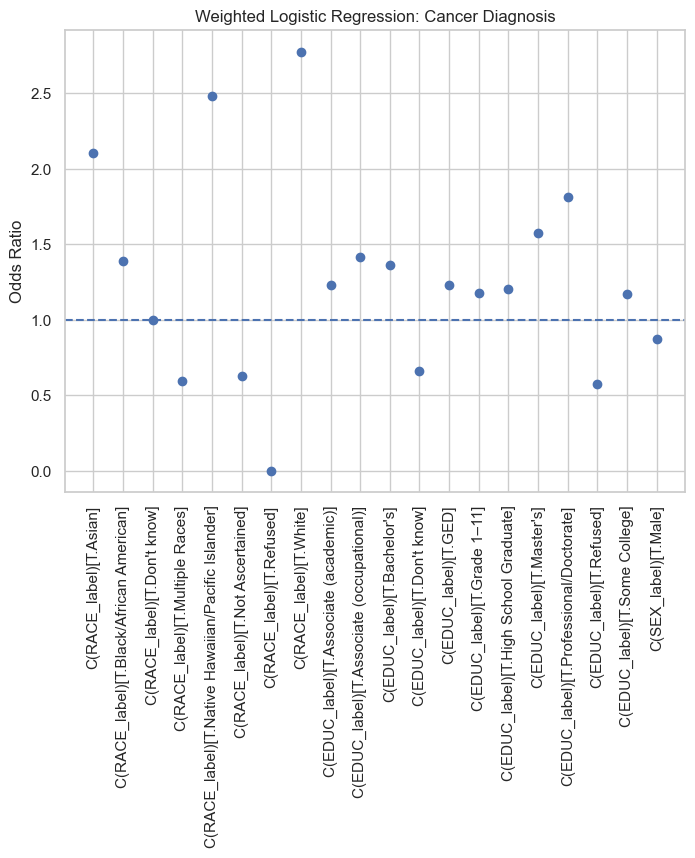

In [233]:
or_table = or_table.drop("Intercept")

plt.figure(figsize=(8,6))

plt.errorbar(
    or_table.index,
    or_table["Odds Ratio"],
    yerr=[
        or_table["Odds Ratio"] - or_table["Lower CI"],
        or_table["Upper CI"] - or_table["Odds Ratio"]
    ],
    fmt='o'
)

plt.axhline(1, linestyle="--")

plt.xticks(rotation=90)
plt.ylabel("Odds Ratio")
plt.title("Weighted Logistic Regression: Cancer Diagnosis")

plt.show()

In [236]:
df["AGEP_A"].describe()

count    32629.000000
mean        53.453278
std         18.673458
min         18.000000
25%         37.000000
50%         55.000000
75%         69.000000
max         99.000000
Name: AGEP_A, dtype: float64